=== BALANCE DE CLASES ===
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64
diagnosis
0    357
1    212
Name: count, dtype: int64


/tmp/ipykernel_2869/1423737100.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=var, ax=axes[i], palette='Set2')
/tmp/ipykernel_2869/1423737100.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])
/tmp/ipykernel_2869/1423737100.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=var, ax=axes[i], palette='Set2')
/tmp/ipykernel_2869/1423737100.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklab

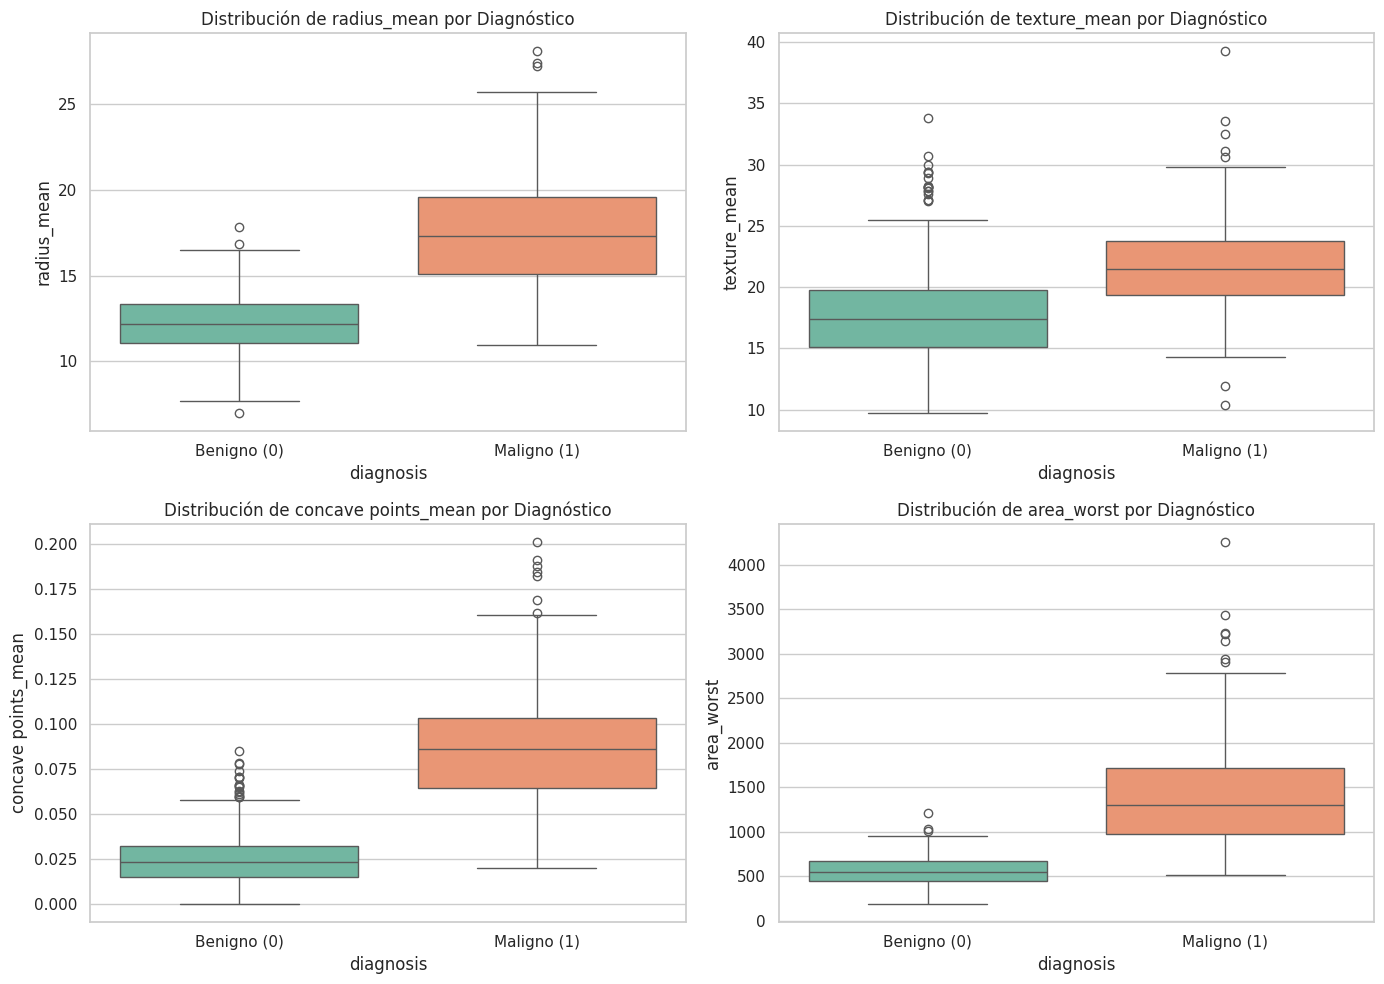

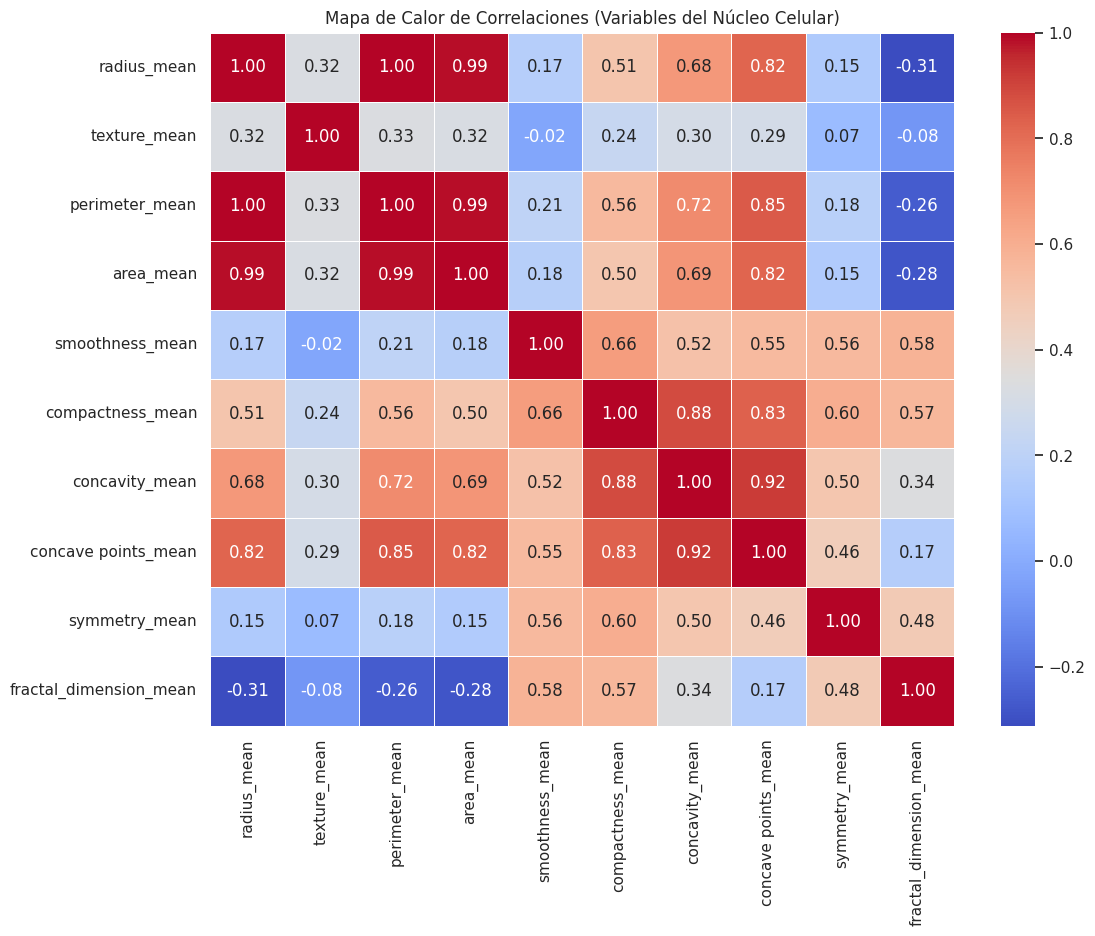

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FORZAR CARGA LIMPIA DE LOS DATOS PARA EVITAR QUE SE PIERDA LA MEMORIA
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación segura de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Configuración de estilo de los gráficos
sns.set_theme(style="whitegrid")
sns.set_palette("deep", desat=0.6)

print("=== BALANCE DE CLASES ===")
print(df['diagnosis'].value_counts(normalize=True))
print(df['diagnosis'].value_counts())

# 2. Boxplots para variables clave con alta capacidad de separación
variables_clave = ['radius_mean', 'texture_mean', 'concave points_mean', 'area_worst']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_clave):
    if var in df.columns:
        sns.boxplot(data=df, x='diagnosis', y=var, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Distribución de {var} por Diagnóstico')
        axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])

plt.tight_layout()
plt.show()

# 3. Mapa de Calor de Correlaciones Seguro (Filtra solo las columnas '_mean' numéricas)
plt.figure(figsize=(12, 9))
cols_mean = [col for col in df.columns if col.endswith('_mean')]
df_mean_numeric = df[cols_mean].select_dtypes(include=[np.number])

sns.heatmap(df_mean_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Variables del Núcleo Celular)')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar Features (X) y Target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].values

# Dividir conjuntos (80% Train, 20% Test) manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ESTRATEGIA ADICIONAL: Eliminar automáticamente variables con correlación > 0.85
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Variables redundantes eliminadas por alta correlación: {to_drop}")
X_train_filtered = X_train.drop(columns=to_drop)
X_test_filtered = X_test.drop(columns=to_drop)

# Escalamiento estándar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

print(f"\nDimensiones finales del set de entrenamiento: {X_train_scaled.shape}")

Variables redundantes eliminadas por alta correlación: ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']

Dimensiones finales del set de entrenamiento: (455, 17)


Varianza explicada por PC1: 38.86%
Varianza explicada por PC2: 13.88%
Varianza acumulada total: 52.74%


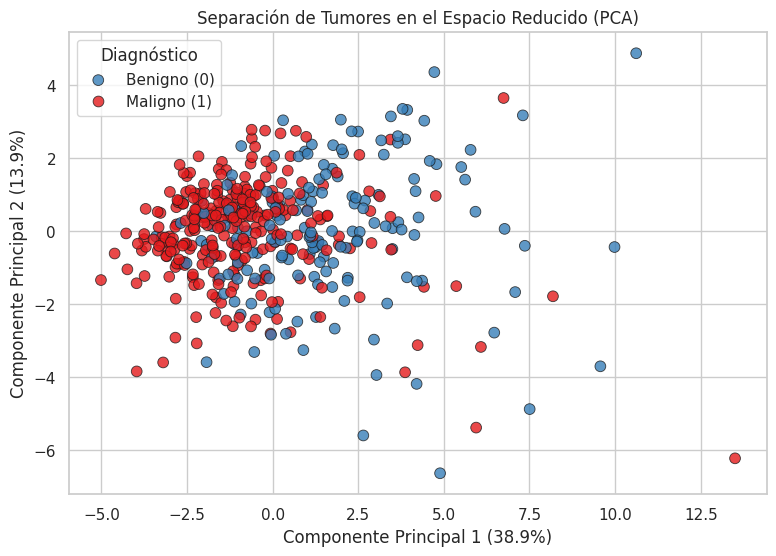

In [6]:
from sklearn.decomposition import PCA

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_exp[1]*100:.2f}%")
print(f"Varianza acumulada total: {sum(var_exp)*100:.2f}%")

# Graficar el espacio reducido
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1', alpha=0.8, edgecolor='k', s=60)
plt.title('Separación de Tumores en el Espacio Reducido (PCA)')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%)')
plt.legend(title='Diagnóstico', labels=['Benigno (0)', 'Maligno (1)'])
plt.show()

Set de Netflix preparado con éxito. Dimensiones: (7045, 17)


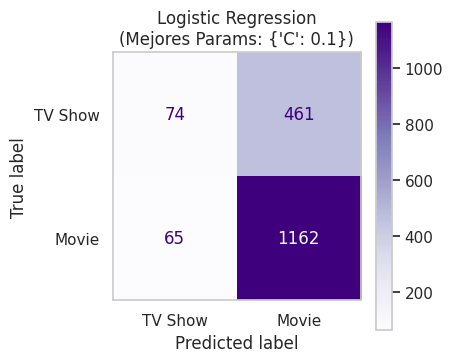

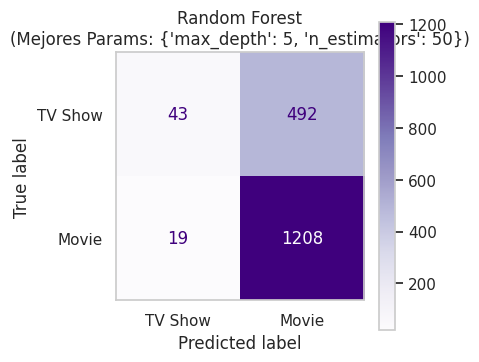


=== TABLA COMPARATIVA DE MODELOS ===


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Logistic Regression,0.701476,0.715958,0.947025,0.815439
Random Forest,0.709989,0.710588,0.984515,0.825419


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# ==============================================================================
# 1. CARGA Y PREPROCESAMIENTO ADAPTADO A TU DATASET DE NETFLIX
# ==============================================================================
# Usamos exactamente la URL que aparece en tus capturas de pantalla
url = "https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv"
df_net = pd.read_csv(url)

# Definimos la variable objetivo: Movie = 1, TV Show = 0
df_net = df_net.dropna(subset=['type', 'release_year'])
df_net['target'] = df_net['type'].map({'Movie': 1, 'TV Show': 0}).astype(int)

# Seleccionamos las características numéricas y categóricas disponibles
X_net = pd.get_dummies(df_net[['release_year', 'rating']], drop_first=True)
y_net = df_net['target'].values

# Dividir conjuntos (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_net, y_net, test_size=0.2, random_state=42, stratify=y_net)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Set de Netflix preparado con éxito. Dimensiones: {X_train_scaled.shape}")

# ==============================================================================
# 2. OPTIMIZACIÓN Y ENTRENAMIENTO DE LOS MODELOS
# ==============================================================================
param_grids = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), {'C': [0.1, 1, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10]})
}

resultados_metricas = []

for nombre, (modelo, params) in param_grids.items():
    # Ajustar grilla usando validación cruzada
    grid = GridSearchCV(modelo, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    # EXTRAER EL MODELO USANDO EL ATRIBUTO CORRECTO CON GUION BAJO: best_estimator_
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)

    # Calcular métricas de rendimiento
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados_metricas.append({
        'Modelo': nombre, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1
    })

    # Graficar matrices de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TV Show', 'Movie'])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(cmap='Purples', ax=ax, values_format='d')
    ax.set_title(f"{nombre}\n(Mejores Params: {grid.best_params_})")
    ax.grid(False)
    plt.show()

# Mostrar la tabla resumen con los resultados
df_resumen = pd.DataFrame(resultados_metricas).set_index('Modelo')
print("\n=== TABLA COMPARATIVA DE MODELOS ===")
display(df_resumen)